# 單張牙科 X-ray：前處理 → SAM 半自動分割 → 標注輸出

這份 notebook 的目的不是直接得到可用於臨床的結果，而是用一張影像理解完整流程：

1. 讀取影像與品質檢查
2. 灰階強度正規化、CLAHE（僅作比較）
3. 建立牙齒 bounding-box prompt
4. 使用 Segment Anything（SAM ViT-B）產生候選 mask
5. 以正／負點修正 mask
6. 做基本後處理與輸出
7. 說明 CEJ、牙冠端與根尖如何銜接到 CRR

> **重要：** SAM 產生的是預標注（pseudo-label），不是醫學 ground truth；mask 必須經人工校正。SAM 也不會自動知道 CEJ 或 root apex 的語義。

## 0. 環境準備

本專案使用 `mcv_env`。SAM 套件與 ViT-B checkpoint 已準備完成。若在新環境重建，可執行：

```bash
uv pip install --python ~/miniconda3/envs/mcv_env/bin/python   'git+https://github.com/facebookresearch/segment-anything.git'
mkdir -p ~/.cache/tooth_ratio
curl -L -o ~/.cache/tooth_ratio/sam_vit_b_01ec64.pth   https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
```

ViT-B checkpoint 約 375 MB。8 GB VRAM 建議先使用 ViT-B，而不是 ViT-H。

In [2]:
from pathlib import Path
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.patches import Rectangle
from segment_anything import SamPredictor, sam_model_registry

plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["image.cmap"] = "gray"

PROJECT_ROOT = Path.cwd()
IMAGE_PATH = PROJECT_ROOT / "data/raw_images/1.jpg"
CHECKPOINT_PATH = Path.home() / ".cache/tooth_ratio/sam_vit_b_01ec64.pth"
OUTPUT_DIR = PROJECT_ROOT / "reports/single_image"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert IMAGE_PATH.exists(), f"找不到影像：{IMAGE_PATH}"
assert CHECKPOINT_PATH.exists(), f"找不到 SAM checkpoint：{CHECKPOINT_PATH}"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print({"image": str(IMAGE_PATH), "checkpoint": str(CHECKPOINT_PATH), "device": DEVICE})

{'image': '/home/cliffyang/Program/Medical-CV/tooth_ratio/data/raw_images/1.jpg', 'checkpoint': '/home/cliffyang/.cache/tooth_ratio/sam_vit_b_01ec64.pth', 'device': 'cuda'}


## 1. 讀取影像與品質檢查

先保留原始解析度，不把影像強制拉伸成正方形。這對 CRR 很重要，因為非等比例縮放會改變長度比例。下面的指標只用於篩查：

- `mean_intensity`：平均亮度
- `contrast_std`：灰階標準差
- `laplacian_variance`：常用的模糊度 proxy，越低通常越模糊

這些指標不能單獨決定影像是否可用，仍需人工檢查。

{
  "width": 825,
  "height": 1200,
  "mean_intensity": 91.95,
  "contrast_std": 64.51,
  "laplacian_variance": 1044.1
}


/home/cliffyang/miniconda3/envs/mcv_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cliffyang/miniconda3/envs/mcv_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cliffyang/miniconda3/envs/mcv_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cliffyang/miniconda3/envs/mcv_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cliffyang/miniconda3/envs/mcv_env/lib/python3.12/site-

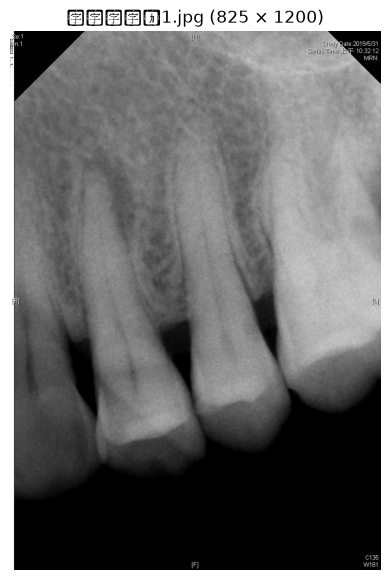

In [3]:
image_bgr = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)
if image_bgr is None:
    raise ValueError(f"OpenCV 無法讀取：{IMAGE_PATH}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
h, w = gray.shape

quality = {
    "width": int(w),
    "height": int(h),
    "mean_intensity": round(float(gray.mean()), 2),
    "contrast_std": round(float(gray.std()), 2),
    "laplacian_variance": round(float(cv2.Laplacian(gray, cv2.CV_64F).var()), 2),
}
print(json.dumps(quality, indent=2, ensure_ascii=False))

fig, ax = plt.subplots()
ax.imshow(image_rgb)
ax.set_title(f"原始影像：{IMAGE_PATH.name} ({w} × {h})")
ax.axis("off")
plt.show()

## 2. 比較三種影像表示

- **Original**：原始灰階
- **Percentile normalization**：把第 1–99 百分位映射到 0–255，降低極端亮暗值影響
- **CLAHE**：局部對比增強，可能讓 CEJ/根部邊界更清楚，但也可能放大雜訊

這裡只做比較。SAM baseline 先使用 percentile-normalized 影像；正式實驗應比較原圖、正規化及 CLAHE，而不是先假設 CLAHE 一定較好。

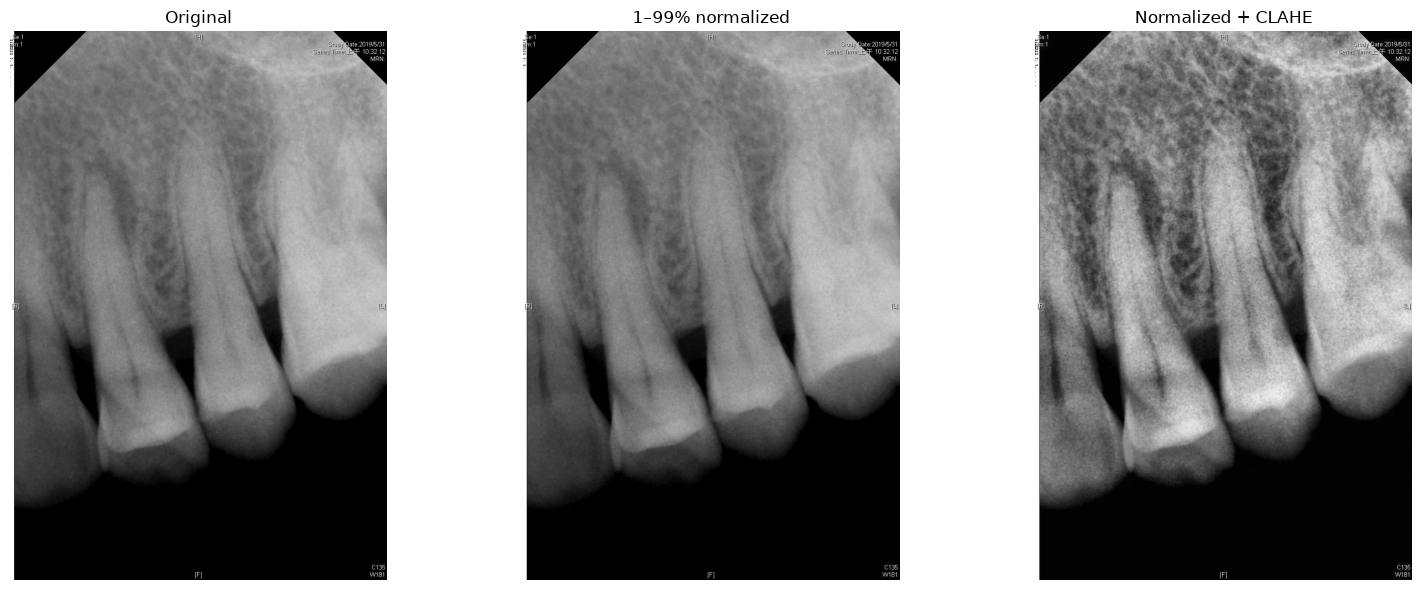

SAM input: (1200, 825, 3) uint8 (0, 255)


In [4]:
def percentile_normalize(image: np.ndarray, low: float = 1.0, high: float = 99.0) -> np.ndarray:
    lo, hi = np.percentile(image, [low, high])
    if hi <= lo:
        return image.copy()
    normalized = (image.astype(np.float32) - lo) / (hi - lo)
    return (np.clip(normalized, 0, 1) * 255).astype(np.uint8)

normalized_gray = percentile_normalize(gray)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_gray = clahe.apply(normalized_gray)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, img, title in zip(
    axes,
    [gray, normalized_gray, clahe_gray],
    ["Original", "1–99% normalized", "Normalized + CLAHE"],
):
    ax.imshow(img, vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

# SAM 接受 H×W×3 的 uint8 RGB；灰階影像複製成三通道即可。
sam_image = cv2.cvtColor(normalized_gray, cv2.COLOR_GRAY2RGB)
print("SAM input:", sam_image.shape, sam_image.dtype, (int(sam_image.min()), int(sam_image.max())))

## 3. 建立 bounding-box prompt

Box prompt 要框住**一顆目標牙齒**並盡量少包含鄰牙。下方先以影像中央區域當示範，請依圖像調整 `BOX_FRACTIONS`：

```text
(x1比例, y1比例, x2比例, y2比例)
```

使用比例而不是固定像素，可讓設定較容易套用到不同解析度；真正標注時仍應逐張框選。

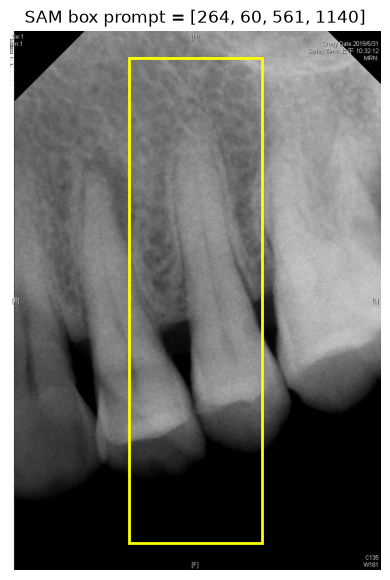

In [5]:
# 可編輯：框選中央目標牙齒。範圍均為 0–1。
BOX_FRACTIONS = (0.32, 0.05, 0.68, 0.95)

x1 = int(BOX_FRACTIONS[0] * w)
y1 = int(BOX_FRACTIONS[1] * h)
x2 = int(BOX_FRACTIONS[2] * w)
y2 = int(BOX_FRACTIONS[3] * h)
input_box = np.array([x1, y1, x2, y2], dtype=np.float32)

fig, ax = plt.subplots()
ax.imshow(sam_image)
ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="yellow", linewidth=2))
ax.set_title(f"SAM box prompt = {input_box.astype(int).tolist()}")
ax.axis("off")
plt.show()

## 4. 載入 SAM ViT-B 並計算影像 embedding

`predictor.set_image()` 會計算一次影像 embedding。對同一張影像嘗試不同 box/point prompts 時，不需要重算 image encoder，因此互動修正速度會快很多。

In [6]:
sam = sam_model_registry["vit_b"](checkpoint=str(CHECKPOINT_PATH))
sam.to(device=DEVICE)
sam.eval()
predictor = SamPredictor(sam)

with torch.inference_mode():
    predictor.set_image(sam_image)

if DEVICE == "cuda":
    allocated_gb = torch.cuda.memory_allocated() / 1024**3
    print(f"SAM 已載入 GPU；目前配置約 {allocated_gb:.2f} GiB")
else:
    print("SAM 使用 CPU；流程相同，但推論會較慢。")

SAM 已載入 GPU；目前配置約 0.38 GiB


## 5. Box-prompt segmentation

`multimask_output=True` 會回傳 3 個候選 mask。`scores` 是 SAM 自己預測的 mask IoU 品質，不等於牙科專家認可的真實 Dice/IoU。先顯示全部候選，再挑最高分作預標注。

masks: (3, 1200, 825)
SAM predicted IoU scores: [0.8718000054359436, 0.8320000171661377, 0.597000002861023]


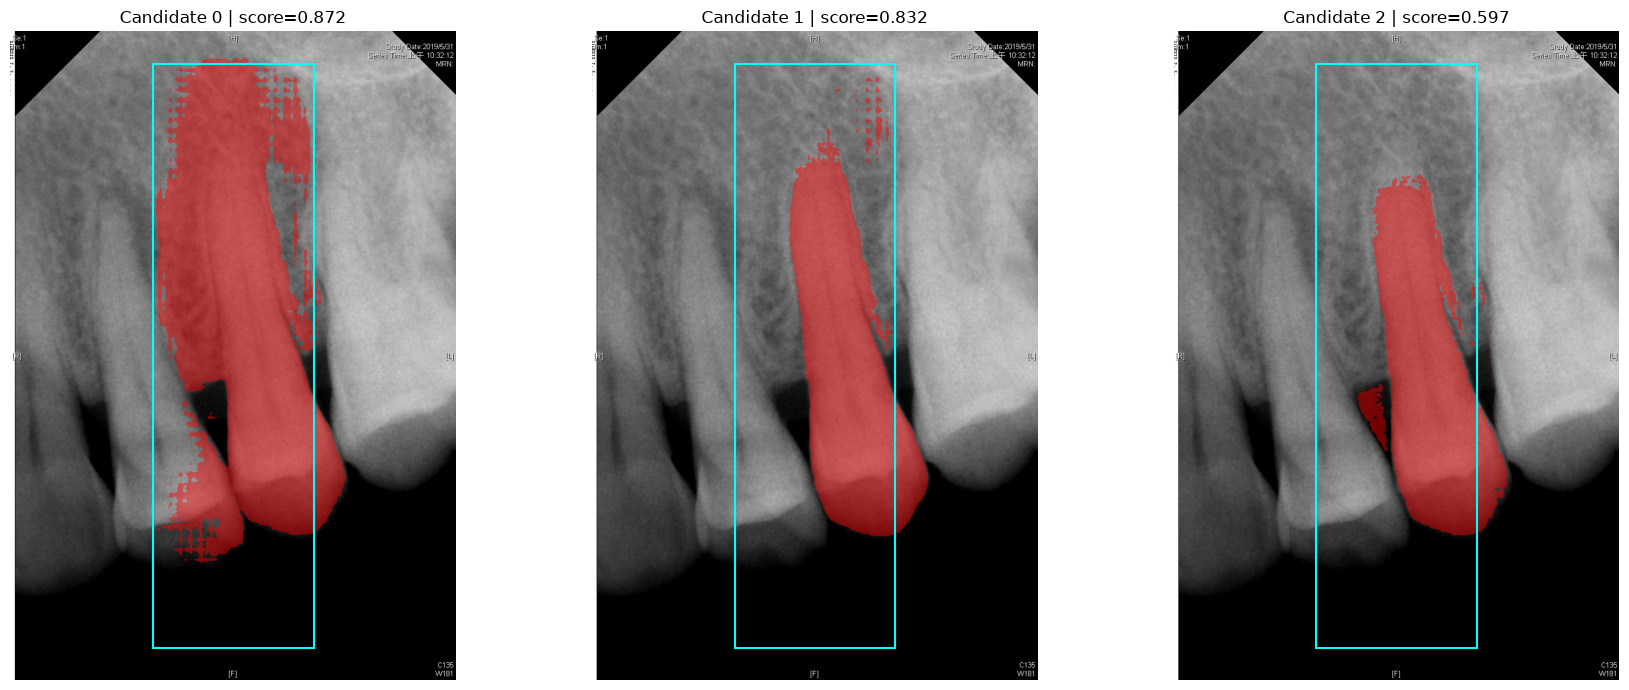

In [7]:
with torch.inference_mode():
    masks, scores, low_res_logits = predictor.predict(
        box=input_box,
        multimask_output=True,
    )

print("masks:", masks.shape)
print("SAM predicted IoU scores:", np.round(scores, 4).tolist())

fig, axes = plt.subplots(1, len(masks), figsize=(18, 7))
for i, (ax, mask, score) in enumerate(zip(axes, masks, scores)):
    ax.imshow(sam_image)
    ax.imshow(np.ma.masked_where(~mask, mask), alpha=0.45, cmap="autumn")
    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="cyan", linewidth=1.5))
    ax.set_title(f"Candidate {i} | score={score:.3f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. 選擇候選並做最小後處理

下面只保留最大連通區並填補小孔，目的是示範如何清除零碎區域。後處理不能修復錯誤的解剖邊界；若 mask 吃到鄰牙，應優先調整 box 或增加負點。

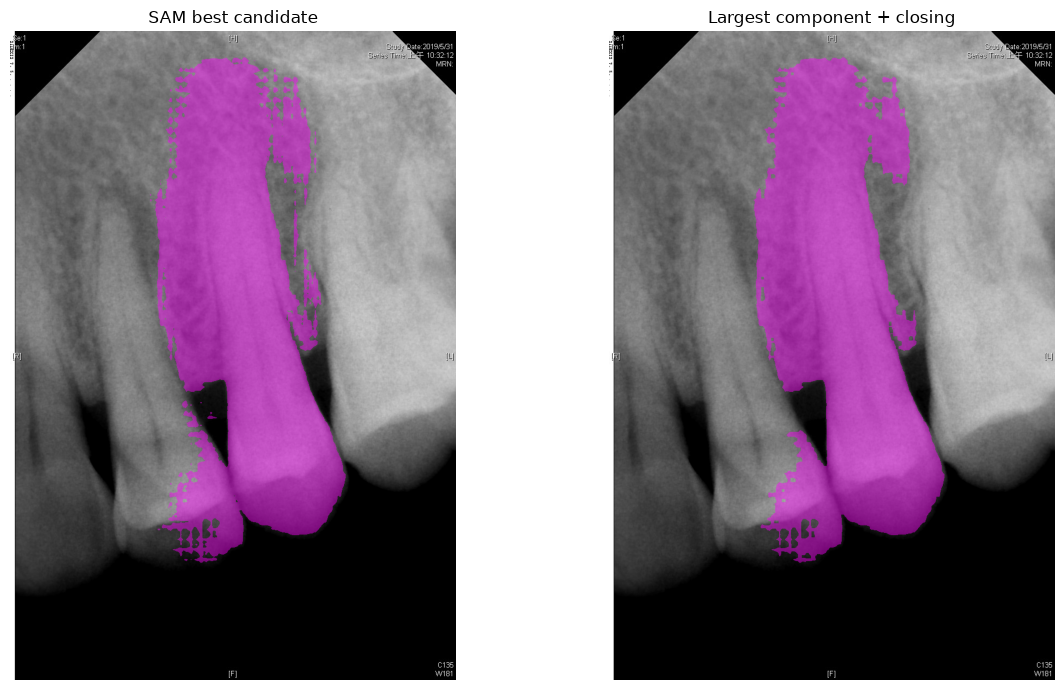

In [8]:
def keep_largest_component(mask: np.ndarray) -> np.ndarray:
    binary = mask.astype(np.uint8)
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if n_labels <= 1:
        return mask.astype(bool)
    largest_label = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    return labels == largest_label

best_index = int(np.argmax(scores))
raw_mask = masks[best_index]
clean_mask = keep_largest_component(raw_mask)

kernel = np.ones((5, 5), np.uint8)
clean_mask = cv2.morphologyEx(clean_mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel).astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, mask, title in zip(axes, [raw_mask, clean_mask], ["SAM best candidate", "Largest component + closing"]):
    ax.imshow(sam_image)
    ax.imshow(np.ma.masked_where(~mask, mask), alpha=0.45, cmap="spring")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. 用正點／負點修正

- 綠色正點（label=1）：希望納入 mask 的區域
- 紅色負點（label=0）：希望排除的鄰牙／骨頭

以下座標只是流程示範。實際標注應由使用者根據顯示結果點選。由於影像 embedding 已經存在，這一步只需重新執行快速的 mask decoder。

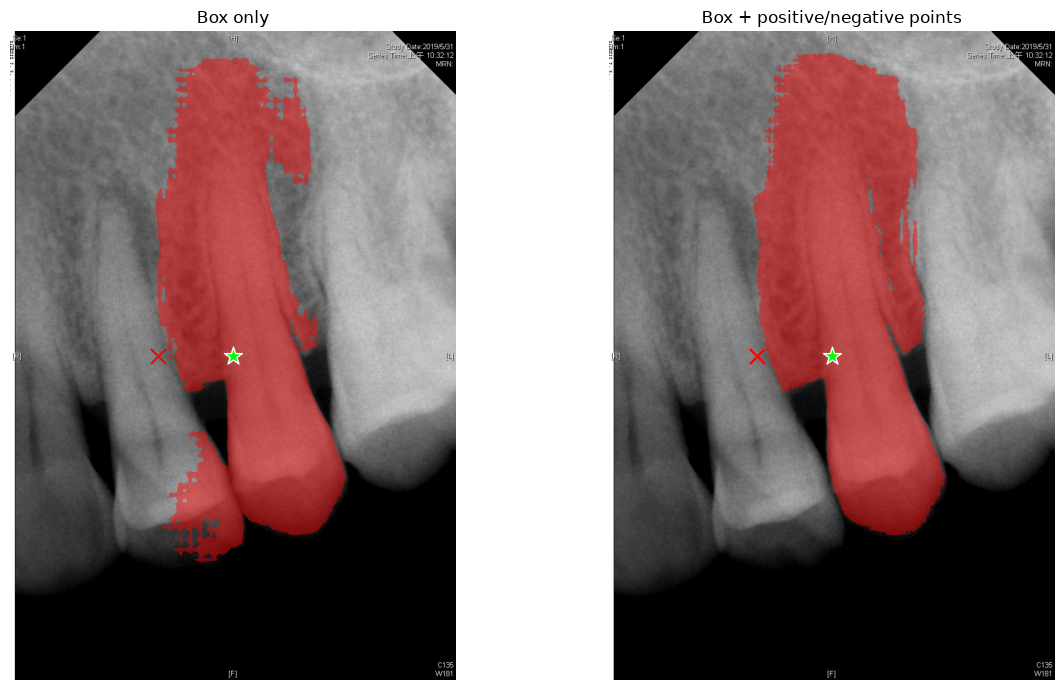

refined score: 0.923


In [9]:
# 示範點：中央為正點；box 左側邊緣內為負點。請依影像調整。
point_coords = np.array([
    [(x1 + x2) / 2, (y1 + y2) / 2],
    [x1 + 0.03 * (x2 - x1), (y1 + y2) / 2],
], dtype=np.float32)
point_labels = np.array([1, 0], dtype=np.int32)

with torch.inference_mode():
    refined_masks, refined_scores, _ = predictor.predict(
        point_coords=point_coords,
        point_labels=point_labels,
        box=input_box,
        multimask_output=False,
    )
refined_mask = keep_largest_component(refined_masks[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, mask, title in zip(axes, [clean_mask, refined_mask], ["Box only", "Box + positive/negative points"]):
    ax.imshow(sam_image)
    ax.imshow(np.ma.masked_where(~mask, mask), alpha=0.45, cmap="autumn")
    ax.scatter(point_coords[point_labels == 1, 0], point_coords[point_labels == 1, 1], c="lime", marker="*", s=180, edgecolors="white")
    ax.scatter(point_coords[point_labels == 0, 0], point_coords[point_labels == 0, 1], c="red", marker="x", s=120)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()
print("refined score:", round(float(refined_scores[0]), 4))

## 8. 基本 sanity check 與輸出

這裡輸出：

- 二值 mask PNG（0=背景，255=前景）
- overlay PNG
- JSON metadata

`mask_fraction` 可用來發現明顯錯誤；例如 mask 幾乎是 0 或覆蓋整張圖。但合理範圍與牙齒大小、裁切方式有關，不能當正式品質標準。

{
  "image": "data/raw_images/1.jpg",
  "model": "sam_vit_b",
  "checkpoint": "sam_vit_b_01ec64.pth",
  "device": "cuda",
  "preprocessing": "grayscale -> 1-99 percentile normalization -> RGB",
  "box_xyxy": [
    264,
    60,
    561,
    1140
  ],
  "point_coords_xy": [
    [
      412.5,
      600.0
    ],
    [
      272.8999938964844,
      600.0
    ]
  ],
  "point_labels": [
    1,
    0
  ],
  "sam_score": 0.923,
  "mask_area_pixels": 207394,
  "mask_fraction": 0.2095,
  "status": "pseudo-label; requires expert correction"
}
saved:
- /home/cliffyang/Program/Medical-CV/tooth_ratio/reports/single_image/1_sam_mask.png
- /home/cliffyang/Program/Medical-CV/tooth_ratio/reports/single_image/1_sam_overlay.png
- /home/cliffyang/Program/Medical-CV/tooth_ratio/reports/single_image/1_sam_metadata.json


/home/cliffyang/miniconda3/envs/mcv_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 36664 (\N{CJK UNIFIED IDEOGRAPH-8F38}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cliffyang/miniconda3/envs/mcv_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cliffyang/miniconda3/envs/mcv_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cliffyang/miniconda3/envs/mcv_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cliffyang/miniconda3/envs/mcv_env/lib/python3.12/site-

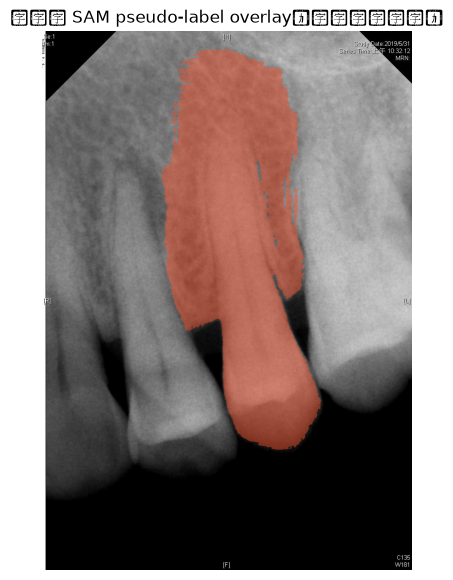

In [10]:
final_mask = refined_mask
mask_area = int(final_mask.sum())
mask_fraction = mask_area / final_mask.size

mask_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_sam_mask.png"
overlay_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_sam_overlay.png"
metadata_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_sam_metadata.json"

cv2.imwrite(str(mask_path), final_mask.astype(np.uint8) * 255)
overlay = image_rgb.copy()
color = np.array([255, 80, 40], dtype=np.uint8)
overlay[final_mask] = (0.55 * overlay[final_mask] + 0.45 * color).astype(np.uint8)
cv2.imwrite(str(overlay_path), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

metadata = {
    "image": str(IMAGE_PATH.relative_to(PROJECT_ROOT)),
    "model": "sam_vit_b",
    "checkpoint": CHECKPOINT_PATH.name,
    "device": DEVICE,
    "preprocessing": "grayscale -> 1-99 percentile normalization -> RGB",
    "box_xyxy": input_box.astype(int).tolist(),
    "point_coords_xy": point_coords.round(1).tolist(),
    "point_labels": point_labels.tolist(),
    "sam_score": round(float(refined_scores[0]), 4),
    "mask_area_pixels": mask_area,
    "mask_fraction": round(float(mask_fraction), 4),
    "status": "pseudo-label; requires expert correction",
}
metadata_path.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")

print(json.dumps(metadata, indent=2, ensure_ascii=False))
print("saved:", mask_path, overlay_path, metadata_path, sep="\n- ")

fig, ax = plt.subplots()
ax.imshow(overlay)
ax.set_title("輸出的 SAM pseudo-label overlay（仍需人工校正）")
ax.axis("off")
plt.show()

## 9. 從 segmentation 到 Crown-to-Root Ratio

牙齒 mask 本身還不夠計算 CRR。下一步至少需要由牙科專家標注：

1. Mesial CEJ
2. Distal CEJ
3. Root apex（多根牙需先規定採哪一根或如何彙整）
4. Crown tip／incisal edge

若採 clinical CRR，還需要 alveolar bone crest，而不是只使用 anatomical CEJ。下方保留量測函式，但不在沒有專家 landmark 的情況下製造假結果。

In [11]:
def projected_distance(point_a, point_b, axis):
    axis = np.asarray(axis, dtype=float)
    axis /= np.linalg.norm(axis)
    return abs(float(np.dot(np.asarray(point_a) - np.asarray(point_b), axis)))

# 需由專家提供，座標格式皆為 (x, y)。
cej_mesial = None
cej_distal = None
root_apex = None
crown_tip = None

if all(point is not None for point in [cej_mesial, cej_distal, root_apex, crown_tip]):
    cej_center = (np.asarray(cej_mesial) + np.asarray(cej_distal)) / 2
    tooth_axis = np.asarray(root_apex) - cej_center
    crown_length = projected_distance(crown_tip, cej_center, tooth_axis)
    root_length = projected_distance(root_apex, cej_center, tooth_axis)
    crr = crown_length / root_length
    print({"crown_px": crown_length, "root_px": root_length, "CRR": crr})
else:
    print("尚未提供專家 landmark，因此不計算 CRR；這可避免輸出看似精確但無醫學依據的數字。")

尚未提供專家 landmark，因此不計算 CRR；這可避免輸出看似精確但無醫學依據的數字。


## 10. 本次單張流程的重點

- 前處理要保留長寬比，不能為了模型方便任意拉伸。
- SAM 對灰階 X-ray 的輸入方式是轉成三通道 RGB。
- 牙科影像優先使用 box prompt；若吃到鄰牙，再加入正／負點。
- SAM score 不是 ground-truth accuracy。
- 輸出的 mask 是預標注，必須由人工校正後才能加入訓練資料。
- CRR 還需要 CEJ、root apex、crown tip／bone crest 等 landmark。

### 建議練習

1. 修改 `IMAGE_PATH`，測試清楚與模糊影像。
2. 改變 `BOX_FRACTIONS`，觀察 box 太大、太小的影響。
3. 移動正點／負點，理解 interactive refinement。
4. 比較 `image_rgb`、`sam_image` 與 CLAHE RGB 作為 SAM 輸入。
5. 把人工校正 mask 保存成 ground truth，再用 Dice/IoU 評估 SAM pseudo-label。